In [4]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv("final_model_dataset.csv")
df["date"] = pd.to_datetime(df["date"])

display(df.head())
display(df.tail())
df.shape

,date,ret_overnight,ret_1d,ret_5d,ret_zscore,close_vs_ma20,close_vs_ma50,momentum_5_20,vol_20d,vol_5d,bn_ret_1d,nifty_bn_corr_20d,vix_ma_ratio,target
0,2022-03-15,0.001740,-0.012346,0.040563,-1.500756,-0.004150,-0.035999,0.051238,0.017837,0.013277,-0.008198,0.956522,1.026399,1
1,2022-03-16,0.012822,0.018745,0.038543,2.149828,0.015662,-0.017189,0.060275,0.016960,0.012826,0.020718,0.952764,0.919979,1
2,2022-03-17,0.013405,0.018362,0.041709,2.104845,0.034420,0.001459,0.043738,0.017498,0.013349,0.019030,0.954926,0.859075,0
3,2022-03-21,0.002456,-0.009802,0.029293,-1.202025,0.024854,-0.007429,0.040099,0.017636,0.015600,-0.011256,0.958270,0.930830,1
4,2022-03-22,0.000164,0.011561,0.026329,1.306340,0.036581,0.004548,0.024060,0.017833,0.015248,0.009163,0.959575,0.906779,0


,date,ret_overnight,ret_1d,ret_5d,ret_zscore,close_vs_ma20,close_vs_ma50,momentum_5_20,vol_20d,vol_5d,bn_ret_1d,nifty_bn_corr_20d,vix_ma_ratio,target
928,2025-12-23,0.001253,0.000181,0.012260,-0.029800,0.006080,0.011714,0.000966,0.005279,0.004176,-0.000075,0.907198,0.882699,0
929,2025-12-24,-0.000248,-0.001339,0.012532,-0.208325,0.004855,0.009645,0.014943,0.004497,0.004113,-0.001955,0.870617,0.876281,0
930,2025-12-26,-0.000798,-0.003818,0.008783,-0.499343,0.001352,0.005095,0.015392,0.004570,0.004949,-0.002910,0.886875,0.883588,0
931,2025-12-29,0.000808,-0.003848,-0.000936,-0.502875,-0.002000,0.000750,0.009019,0.004638,0.004847,-0.001339,0.881065,0.947322,0
932,2025-12-30,-0.000046,-0.000125,-0.008924,-0.065819,-0.001670,0.000352,0.000127,0.004637,0.001950,0.004054,0.858002,0.952475,1


(933, 14)

In [6]:
X = df.drop(columns=["date", "target"])       #feature df
y = df["target"]                              # target df
dates = df["date"] 

print(X.shape)
print(y.shape)

(933, 12)
(933,)


In [7]:
# identify class balance

display(y.value_counts(normalize=True))     #aligns with nifty growth- more 1s
print("Majority Class:", y.value_counts().idxmax())

target
1    0.53269
0    0.46731
Name: proportion, dtype: float64

Majority Class: 1


In [8]:
# split
is_df = df[ df["date"]<"2025-07-01" ].copy()       #in sample df
oos_df = df[ df["date"]>="2025-07-01" ].copy()     #out of sample df

print(is_df.shape)
print(oos_df.shape)

(808, 14)
(125, 14)


In [9]:
# train-test split into feature and target

X_is_train = is_df.drop(columns=["date", "target"])
y_is_train = is_df["target"]

X_oos_test = oos_df.drop(columns=["date", "target"])
y_oos_test = oos_df["target"]

print(X_is_train.shape)
print(X_oos_test.shape)

(808, 12)
(125, 12)


## Baseline Values from data

In [13]:
from sklearn.metrics import accuracy_score

In [14]:
# Majority class(1) baseline acc.

majority_pred = np.ones(len(y_oos_test))
majority_acc = accuracy_score(y_oos_test, majority_pred)

print("Majority Baseline Accuracy:", np.round(majority_acc,4))

Majority Baseline Accuracy: 0.512


In [15]:
# Persistence baseline acc.

persistence_pred = y_oos_test.shift(1).dropna()      #prev. day true => today prediction
persistence_true = y_oos_test.iloc[1:]

persistence_acc = accuracy_score(persistence_true, persistence_pred)

print("Persistence Baseline Accuracy:", np.round(persistence_acc,4))

Persistence Baseline Accuracy: 0.5887


In [17]:
# Walk forward validation

In [18]:
from sklearn.model_selection import TimeSeriesSplit

In [19]:
ts = TimeSeriesSplit(n_splits=5)

In [20]:
fold = 1
for train_idx, val_idx in ts.split(X_is_train):
    print("Fold", fold)
    print("Train:", train_idx[0], "to", train_idx[-1])
    print("Validation:", val_idx[0], "to", val_idx[-1])
    fold+=1

Fold 1
Train: 0 to 137
Validation: 138 to 271
Fold 2
Train: 0 to 271
Validation: 272 to 405
Fold 3
Train: 0 to 405
Validation: 406 to 539
Fold 4
Train: 0 to 539
Validation: 540 to 673
Fold 5
Train: 0 to 673
Validation: 674 to 807


In [22]:
#-----MODEL TRANING using XGB--------

In [23]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [25]:
model = XGBClassifier(
    n_estimators=80,
    max_depth=1,
    learning_rate=0.02,

    min_child_weight=10,

    subsample=0.7,
    colsample_bytree=0.7,

    reg_alpha=2,
    reg_lambda=8,

    random_state=42
)

In [31]:
# walk-forward CV inside in-sample data (training set)

cv_scores = []

for fold, (train_idx, val_idx) in enumerate(ts.split(X_is_train)):

    X_train_fold = X_is_train.iloc[train_idx]
    y_train_fold = y_is_train.iloc[train_idx]

    X_val_fold = X_is_train.iloc[val_idx]
    y_val_fold = y_is_train.iloc[val_idx]

    model.fit(X_train_fold, y_train_fold)

    val_pred = model.predict(X_val_fold)

    acc = accuracy_score(y_val_fold, val_pred)

    cv_scores.append(acc)

    print(f"Fold {fold+1} Accuracy:", round(acc, 4))
    
print("Mean CV Accuracy:", round(np.mean(cv_scores),4) )

Fold 1 Accuracy: 0.5448
Fold 2 Accuracy: 0.597
Fold 3 Accuracy: 0.5373
Fold 4 Accuracy: 0.5746
Fold 5 Accuracy: 0.4701
Mean CV Accuracy: 0.5448


In [40]:
# testset evaluation on oos data

model.fit(X_is_train, y_is_train)

oos_pred = model.predict(X_oos_test)

oos_acc = accuracy_score(y_oos_test, oos_pred)

print("OOS Accuracy:", oos_acc)

OOS Accuracy: 0.52


In [47]:
# first attempt - OOS Accuracy: 0.504
# Second attempt - OOS Accuracy: 0.528

In [49]:
# checking feature importance
feature_importance = pd.DataFrame({
    "feature": X_is_train.columns,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance

,feature,importance
2,ret_5d,0.332801
3,ret_zscore,0.143393
8,vol_5d,0.097195
1,ret_1d,0.071340
4,close_vs_ma20,0.067841
7,vol_20d,0.067731
0,ret_overnight,0.067702
9,bn_ret_1d,0.061658
6,momentum_5_20,0.053900
5,close_vs_ma50,0.036439


In [52]:
# ----- ANALYSE PREDICTION AND PROBABILITIES --------

In [56]:
oos_prob = model.predict_proba(X_oos_test)[:, 1]

prob_df = pd.DataFrame({
    "actual": y_oos_test,
    "pred_prob_up": oos_prob,
    "pred_class": oos_pred
})

prob_df.head(20)

,actual,pred_prob_up,pred_class
808,0,0.593582,1
809,0,0.581156,1
810,1,0.586097,1
811,1,0.594702,1
812,1,0.568973,1
813,0,0.570472,1
814,0,0.566643,1
815,0,0.582996,1
816,0,0.509956,1
817,1,0.561294,1


In [67]:
# checking prob. distribution
prob_df["pred_prob_up"].describe()

count    125.000000
mean       0.566375
std        0.031624
min        0.491373
25%        0.546844
50%        0.575017
75%        0.590733
max        0.609321
Name: pred_prob_up, dtype: float64

<Axes: >

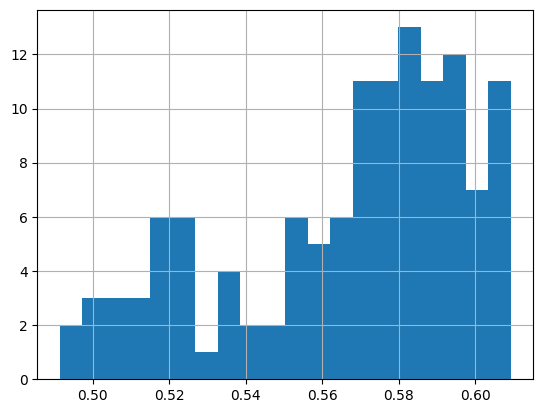

In [69]:
prob_df["pred_prob_up"].hist(bins=20)             #slight bullish bias(attempt 1)

In [71]:
# high confidence predictions
high_conf_df = prob_df[prob_df["pred_prob_up"] > 0.60]

high_conf_acc = accuracy_score(
    high_conf_df["actual"],
    high_conf_df["pred_class"]
)

print("Out of 125 OOS days")
print("High Confidence Trades:", len(high_conf_df))
print("High Confidence Accuracy:", high_conf_acc)

Out of 125 OOS days
High Confidence Trades: 15
High Confidence Accuracy: 0.4666666666666667


In [73]:
thresholds = [0.55, 0.60, 0.65, 0.70]

for th in thresholds:

    temp_df = prob_df[prob_df["pred_prob_up"] > th]

    if len(temp_df) > 0:

        temp_acc = accuracy_score(
            temp_df["actual"],
            temp_df["pred_class"]
        )

        print(
            f"Threshold {th} | "
            f"Trades: {len(temp_df)} | "
            f"Accuracy: {round(temp_acc,4)}"
        )

Threshold 0.55 | Trades: 93 | Accuracy: 0.5484
Threshold 0.6 | Trades: 15 | Accuracy: 0.4667


In [75]:
# probability threshold tuning

threshold = 0.60

oos_pred = (oos_prob > threshold).astype(int)

from sklearn.metrics import accuracy_score

print(
    "Threshold Accuracy:",
    round(accuracy_score(y_oos_test, oos_pred), 4)
)

Threshold Accuracy: 0.48


In [77]:
# standard classification metrics

# reduced bullish bias

from sklearn.metrics import confusion_matrix, balanced_accuracy_score, roc_auc_score


auc = roc_auc_score(y_oos_test, oos_prob)

cm = confusion_matrix(y_oos_test, oos_pred)

bal_acc = balanced_accuracy_score(y_oos_test,oos_pred)

print("AUC:", round(auc, 4))

print("Balanced Accuracy:", round(bal_acc, 4))

print("\nConfusion Matrix:")
print(cm)

AUC: 0.5432
Balanced Accuracy: 0.4891

Confusion Matrix:
[[53  8]
 [57  7]]


In [79]:
(oos_pred == 1).mean()

np.float64(0.12)

In [ ]:
### earlier

# AUC: 0.568
# Balanced Accuracy: 0.5175

# Confusion Matrix:
# [[ 5 56]
#  [ 3 61]]

In [ ]:
#  trading backtest metrics

oos_returns = oos_df["ret_1d"].reset_index(drop=True)

strategy_df = pd.DataFrame({
    "actual_return": oos_returns,
    "prediction": oos_pred
})

strategy_df["strategy_return"] = (strategy_df["actual_return"] * strategy_df["prediction"])

strategy_df.head()

In [ ]:
# cumulative returns
import matplotlib.pyplot as plt

strategy_df["cum_market_return"] = (1 + strategy_df["actual_return"]).cumprod()

strategy_df["cum_strategy_return"] = (1 + strategy_df["strategy_return"]).cumprod()

strategy_df[["cum_market_return","cum_strategy_return"]].plot(figsize=(10,5))
plt.xlabel("Trading Days")
plt.ylabel("Cumulative Return")

plt.title("Market vs Strategy Performance")

In [ ]:
#  strategy appears to avoid some down periods & participate in stronger up periods- hence beats mkt (attempt 1)
# assumption - txn costs/penalty not included

In [ ]:
# sharpe, hitrate, turnover

In [ ]:
sharpe = (strategy_df["strategy_return"].mean() /strategy_df["strategy_return"].std()) * np.sqrt(252)

hit_rate = (strategy_df["strategy_return"] > 0).mean()

turnover = (strategy_df["prediction"].diff().abs().sum())

print("Sharpe Ratio:", round(sharpe,4))
print("Hit Rate:", round(hit_rate,4))
print("Turnover:", turnover)

In [ ]:
rolling_max = strategy_df["cum_strategy_return"].cummax()

drawdown = (
    strategy_df["cum_strategy_return"] -
    rolling_max
) / rolling_max

max_drawdown = drawdown.min()

print("Max Drawdown:", round(max_drawdown,4))

In [ ]:
summary_df = pd.DataFrame({
    "Metric": [
        "Majority Baseline",
        "Persistence Baseline",
        "CV Accuracy",
        "OOS Accuracy",
        "AUC",
        "Balanced Accuracy",
        "Sharpe Ratio",
        "Hit Rate",
        "Turnover",
        "Max Drawdown"
    ],

    "Value": [
        majority_acc,
        persistence_acc,
        np.mean(cv_scores),
        oos_acc,
        auc,
        bal_acc,
        sharpe,
        hit_rate,
        turnover,
        max_drawdown
    ]
})

summary_df